In [1]:
# ! pip install healpy numpyro corner arviz optax reproject einops seaborn chainconsumer blackjax

In [1]:
! nvidia-smi --query-gpu=name --format=csv,noheader

Tesla V100-PCIE-32GB


In [10]:
import sys
import pickle
sys.path.append("../")

from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import corner
import matplotlib.pyplot as plt

from models.np_model import NPModel

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
r_outer = 25
l_max = 0
vary_disk = False
bulge_hybrid = False
vary_gamma = False

dif = "ModelO"
ps_cat = "3fgl"
nside = 128

npmodel = NPModel(dif=dif, r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, bulge_hybrid=bulge_hybrid, vary_gamma=vary_gamma, ps_cat=ps_cat, nside=nside)
svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=5000)

arviz_post = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=50000)
posterior = arviz_post.to_dict()['posterior']

Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2.npy


100%|██████████| 5000/5000 [03:09<00:00, 26.41it/s, init loss: 27595.8194, avg. loss [4751-5000]: 20090.7603]


In [17]:
posterior['logZ'] = np.array(jnp.mean(svi_results.losses[-250:]))

In [18]:
# posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

# with open(posterior_file, 'wb') as outfile:
#     pickle.dump(posterior, outfile, protocol=pickle.HIGHEST_PROTOCOL)

In [19]:
# # Load data (deserialize)
# with open(posterior_file, 'rb') as handle:
#     posterior = pickle.load(handle)

### Probabilistic model

/n/home11/smsharma/.local/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/n/home11/smsharma/.local/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


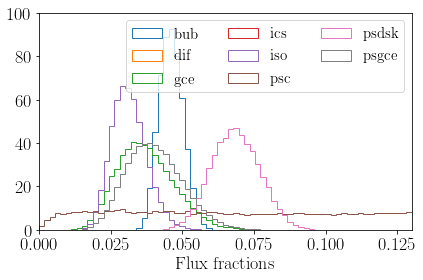

In [20]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])[:, 0, :]
S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])

flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]

ff_max = 0.13
ff_bins = 70x

bins = np.linspace(0, ff_max, ff_bins)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", "")[1:], histtype='step', density=True)
    
plt.xlim(0, ff_max)
plt.ylim(0, 100)
plt.legend(ncol=3, fontsize=15)

plt.xlabel("Flux fractions")

plt.tight_layout()
# plt.savefig("prob_prog_results/ff_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

/n/home11/smsharma/.local/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/n/home11/smsharma/.local/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


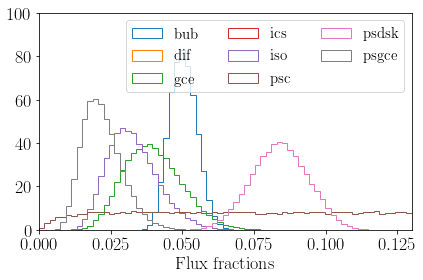

In [15]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])[:, 0, :]
S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])

flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]

ff_max = 0.13
ff_bins = 70

bins = np.linspace(0, ff_max, ff_bins)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", "")[1:], histtype='step', density=True)
    
plt.xlim(0, ff_max)
plt.ylim(0, 100)
plt.legend(ncol=3, fontsize=15)

plt.xlabel("Flux fractions")

plt.tight_layout()
# plt.savefig("prob_prog_results/ff_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

In [5]:
import pandas as pd

def get_ff(posterior):
    
    S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])[:, 0, :]
    S_labels = np.array([k[1:].replace("_", "") for k,v in posterior.items() if k.startswith('S')])

    flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]
    
    return pd.DataFrame(flux_fraction_post.T * 100, columns=S_labels)


Text(0.5, 1.0, 'Stellar bulge; $\\log\\mathcal Z \\simeq$ 18979.8')

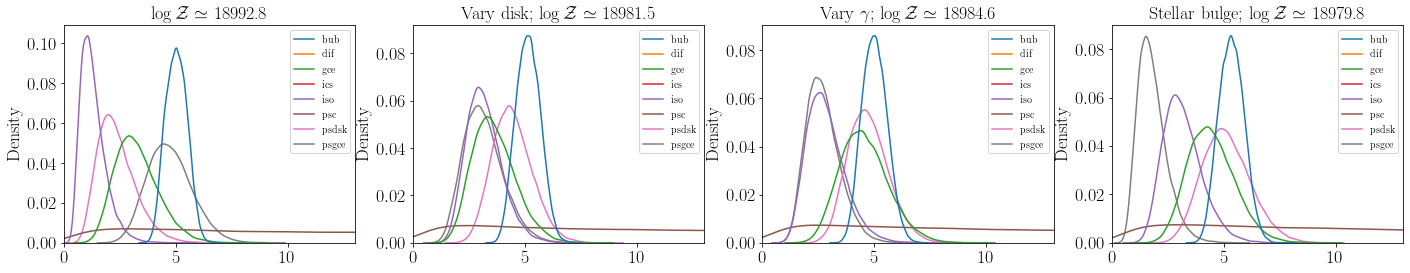

In [52]:
import seaborn as sns

ff_max = 13

fig, ax = plt.subplots(1, 4, figsize=(24, 4))

##

r_outer = 25
l_max = 0
vary_disk = False
bulge_hybrid = False
vary_gamma = False
dif = "ModelO"

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

df = get_ff(posterior)

sns.kdeplot(data=df, ax=ax[0])
ax[0].set_xlim(0, ff_max)
ax[0].set_title(r"$\log\mathcal Z \simeq$ " + "{0:.6g}".format(posterior["logZ"]))

##

r_outer = 25
l_max = 0
vary_disk = True
bulge_hybrid = False
vary_gamma = False
dif = "ModelO"

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

df = get_ff(posterior)

sns.kdeplot(data=df, ax=ax[1])
ax[1].set_xlim(0, ff_max)
ax[1].set_title(r"Vary disk; $\log\mathcal Z \simeq$ " + "{0:.6g}".format(posterior["logZ"]))

##

r_outer = 25
l_max = 0
vary_disk = True
bulge_hybrid = False
vary_gamma = True
dif = "ModelO"

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

df = get_ff(posterior)

sns.kdeplot(data=df, ax=ax[2])
ax[2].set_xlim(0, ff_max)
ax[2].set_title(r"Vary $\gamma$; $\log\mathcal Z \simeq$ " + "{0:.6g}".format(posterior["logZ"]))

##

r_outer = 25
l_max = 0
vary_disk = True
bulge_hybrid = True
vary_gamma = True
dif = "ModelO"

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

df = get_ff(posterior)

sns.kdeplot(data=df, ax=ax[3])
ax[3].set_xlim(0, ff_max)
ax[3].set_title(r"Stellar bulge; $\log\mathcal Z \simeq$ " + "{0:.6g}".format(posterior["logZ"]))


In [15]:
# Disk viz

r_outer = 25
l_max = 0
vary_disk = True
bulge_hybrid = False
vary_gamma = False
dif = "ModelO"

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

zs_post = np.array([v for k,v in posterior.items() if k.startswith('zs')])[:, 0, :]
C_post = np.array([v for k,v in posterior.items() if k.startswith('C')])[:, 0, :]

from models.templates import LorimerDiskTemplate
import healpy as hp

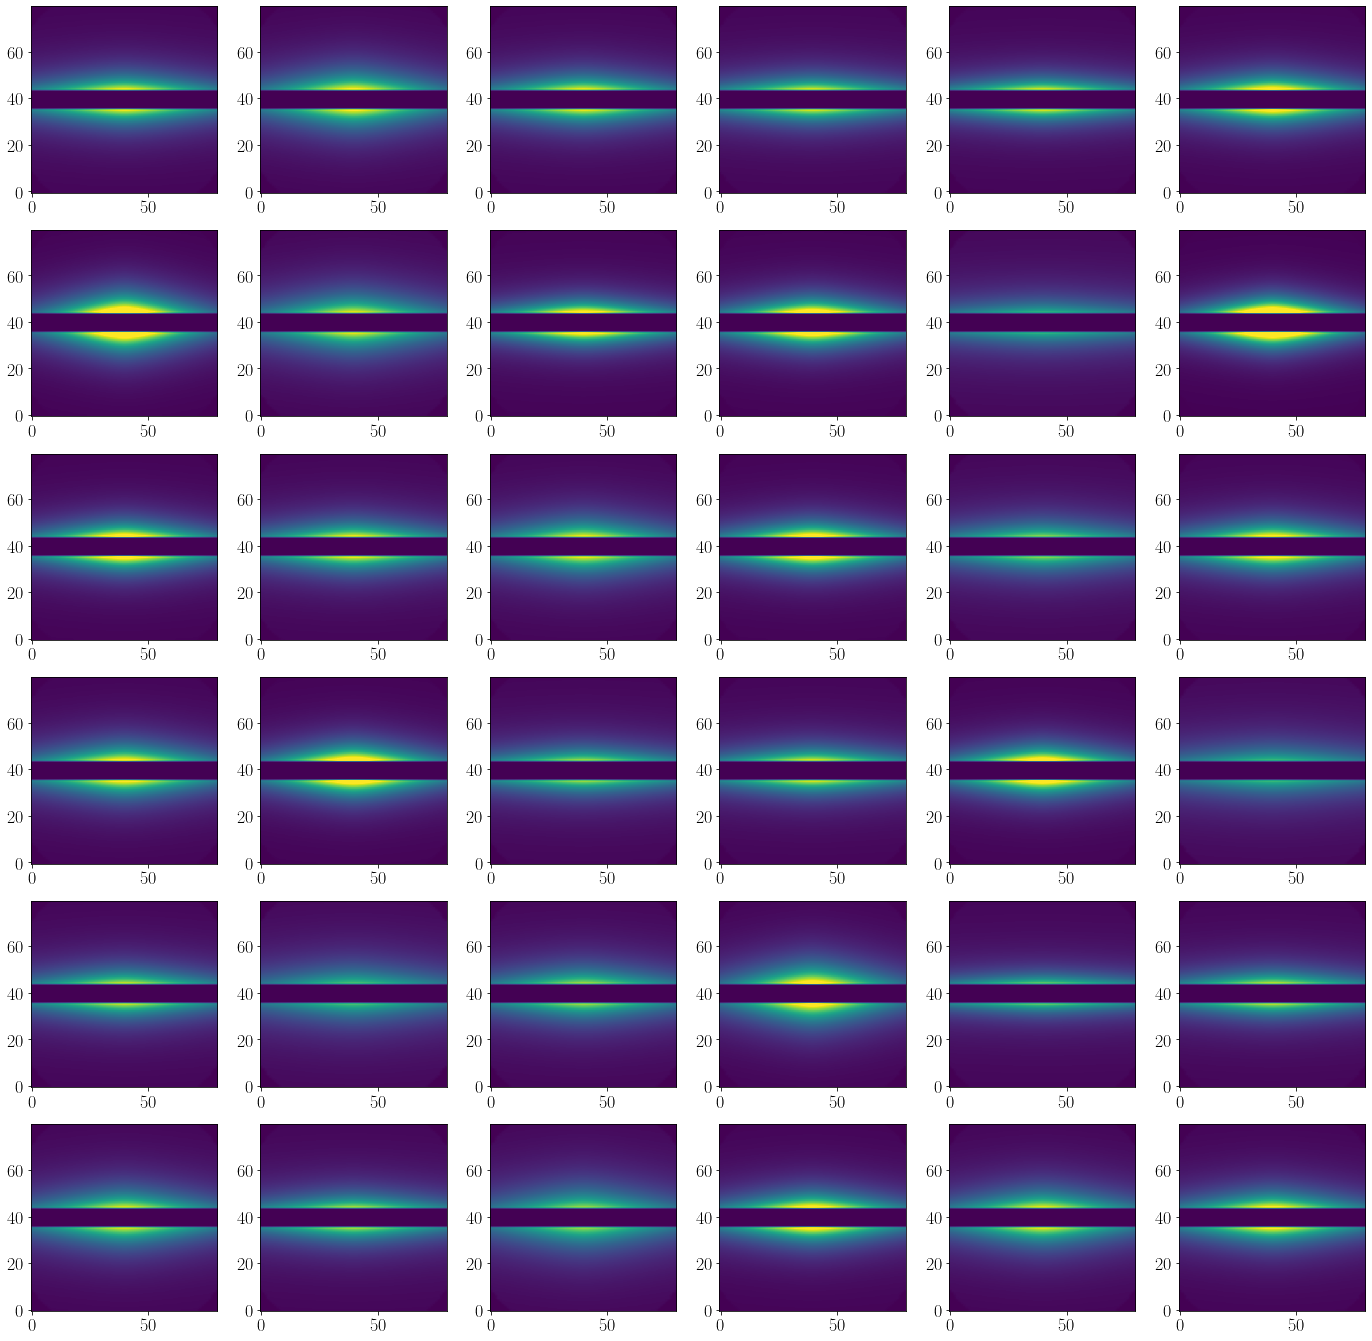

In [42]:
from utils.cart import to_cart
from tqdm.notebook import tqdm

extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 128

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(24, 24))
gs = GridSpec(6, 6)

for i in (range(36)):
    
    ax = fig.add_subplot(gs[i])
    
    ii = np.random.randint(50000)
    
    # Load standard templates and convert to Cartesian
    cart = to_cart(~npmodel.mask_plane * np.array(LorimerDiskTemplate().get_template(zs=zs_post[0, ii], B=0., C=C_post[0, ii])), n_pixels=n_pixels, pixelsize=pixelsize)
    ax.imshow(cart, vmax=0.1, origin='lower')

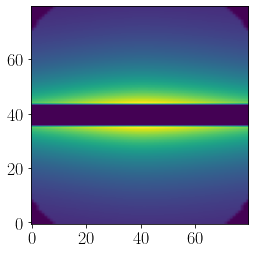

In [24]:
cart = to_cart(~npmodel.mask_plane * npmodel.temp_dsk, n_pixels=n_pixels, pixelsize=pixelsize)
plt.imshow(cart, origin='lower')

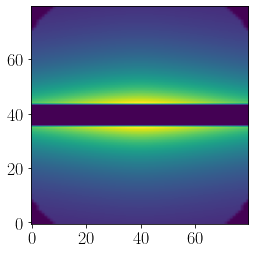

In [34]:
cart = to_cart(~npmodel.mask_plane * np.array(LorimerDiskTemplate().get_template(zs=1., B=0., C=2.)), n_pixels=n_pixels, pixelsize=pixelsize)
plt.imshow(cart, origin='lower')

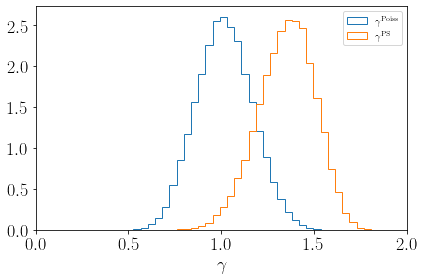

In [38]:
r_outer = 25
l_max = 0
vary_disk = True
bulge_hybrid = False
vary_gamma = True
dif = "ModelO"

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

S_post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])[:, 0, :]
S_labels = [r"$\gamma^\mathrm{Poiss}$",r"$\gamma^\mathrm{PS}$"]

flux_fraction_post = S_post

bins = np.linspace(0.1, 2., 50)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True)
    
plt.legend()
plt.xlim(0, 2.)

plt.xlabel(r"$\gamma$")

plt.tight_layout()
# # plt.savefig("prob_prog_results/gamma_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

In [39]:
# S_post = np.array([v for k,v in posterior.items() if k.startswith('zs')])[:, 0, :]

# flux_fraction_post = S_post

# bins = np.linspace(0.1, 1.5, 75)
# for i in range(len(flux_fraction_post)):
#     plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True)
    
# plt.xlabel("$z_\mathrm{s}$")

# plt.tight_layout()
# # plt.savefig("prob_prog_results/zs_dif_{}_r_{}_lmax_{}_x.pdf".format(dif, r_outer, lmax))

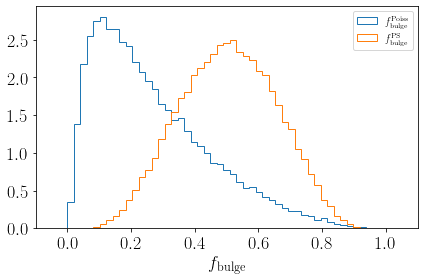

In [41]:
# Disk viz

r_outer = 25
l_max = 0
vary_disk = True
bulge_hybrid = True
vary_gamma = True
dif = "ModelO"

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}.pdf".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma)

with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

S_post = np.array([v for k,v in posterior.items() if k.startswith('f_bulge')])[:, 0, :]
S_labels = [r"$f_\mathrm{bulge}^\mathrm{Poiss}$",r"$f_\mathrm{bulge}^\mathrm{PS}$"]

flux_fraction_post = S_post

bins = np.linspace(0., 1., 50)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i], histtype='step', density=True)
    
plt.xlim(-0.1, 1.1)
plt.legend()

plt.xlabel(r"$f_\mathrm{bulge}$")

plt.tight_layout()
# # plt.savefig("prob_prog_results/fbulge_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

In [15]:
# temps_include = ['Sps_gceps', 'S_gce', 'gamma_poiss', 'gamma_ps']
# S_post = np.array([v for k,v  in posterior.items()])
# S_labels = np.array([k for k,v  in posterior.items()])

# corner.corner(S_post.T, labels=[t.replace("_", "") for t in S_labels]);

In [16]:
# corner.corner(arviz_post);

In [17]:
# from numpyro.infer import MCMC, HMCECS, NUTS, Predictive

In [18]:
# nuts_kernel = NUTS(model, dense_mass=True, max_tree_depth=3)
# kernel = HMCECS(nuts_kernel, num_blocks=10)

# mcmc = MCMC(kernel, num_samples=4000, num_warmup=500)
# rng_key = random.PRNGKey(0)
# mcmc.run(rng_key, data, subsample_size=int(0.8 * len(data[~mask_roi])))

In [19]:
# arviz_post = az.from_dict(mcmc.get_samples())
# corner.corner(arviz_post);

## BlackJax stuff

In [ ]:
# from numpyro.infer.util import initialize_model

# npmodel = NPModel(data, dif="ModelO", vary_disk=False, bulge_hybrid=False, vary_gamma=False)

# rng_key = jax.random.PRNGKey(0)
# init_params, potential_fn_gen, *_ = initialize_model(
#     rng_key,
#     npmodel.model,
#     model_args=(data,),
#     dynamic_args=True,
# )

# logprob_fn = lambda position: -potential_fn_gen(data,)(position)
# initial_position = init_params.z

# import blackjax

# num_warmup = 10

# adapt = blackjax.window_adaptation(
#     blackjax.nuts, logprob_fn, num_warmup, target_acceptance_rate=0.8, progress_bar=True
# )
# last_state, kernel, _ = adapt.run(rng_key, initial_position)

# def inference_loop(rng_key, kernel, initial_state, num_samples):
#     @jax.jit
#     def one_step(state, rng_key):
#         state, _ = kernel(rng_key, state)
#         return state, state

#     keys = jax.random.split(rng_key, num_samples)
#     _, states = jax.lax.scan(one_step, initial_state, keys)

#     return states

# states = inference_loop(rng_key, kernel, last_state, 100)

# loc_samples = states.position["loc"].block_until_ready()
# scale_samples = states.position["scale"]